✅ Librerías importadas correctamente

↗️ Sube el archivo: beepi_dataset_naive_bayes.xlsx


Saving beepi_dataset.xlsx to beepi_dataset (1).xlsx

✅ Dataset cargado correctamente
   Archivo      : beepi_dataset (1).xlsx
   Registros    : 50
   Distribución : {'Compra': 36, 'No Compra': 14}

⚙️  Preprocesando variables...
   Train: 40 | Test: 10

🧠 Entrenando Gaussian Naive Bayes...
   Accuracy Test  : 70.00%
   CV 5-Fold      : 76.00% ± 12.00%

              precision    recall  f1-score   support

      Compra       0.70      1.00      0.82         7
   No Compra       0.00      0.00      0.00         3

    accuracy                           0.70        10
   macro avg       0.35      0.50      0.41        10
weighted avg       0.49      0.70      0.58        10


📊 Generando Gráfico 1 — Comportamiento del Dataset...


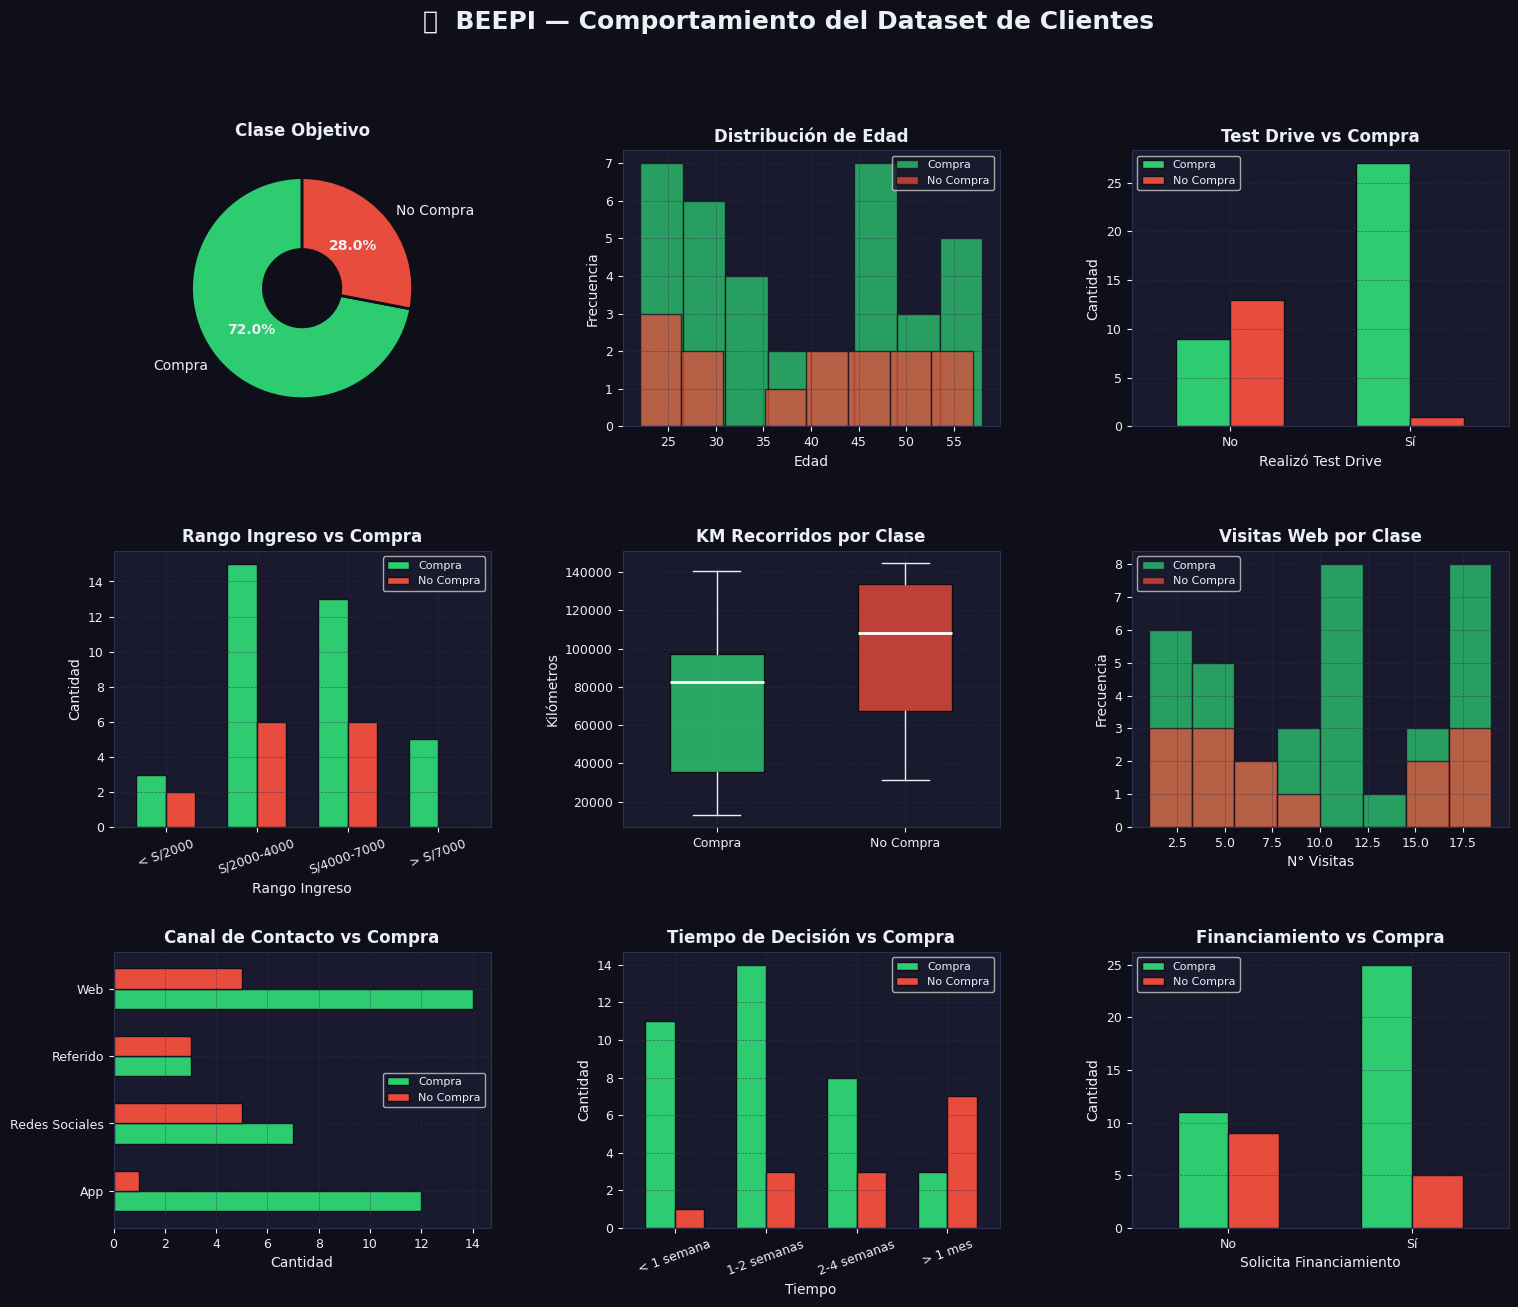

   ✅ grafico1_comportamiento_dataset.png

📊 Generando Gráfico 2 — Resultados Naive Bayes...


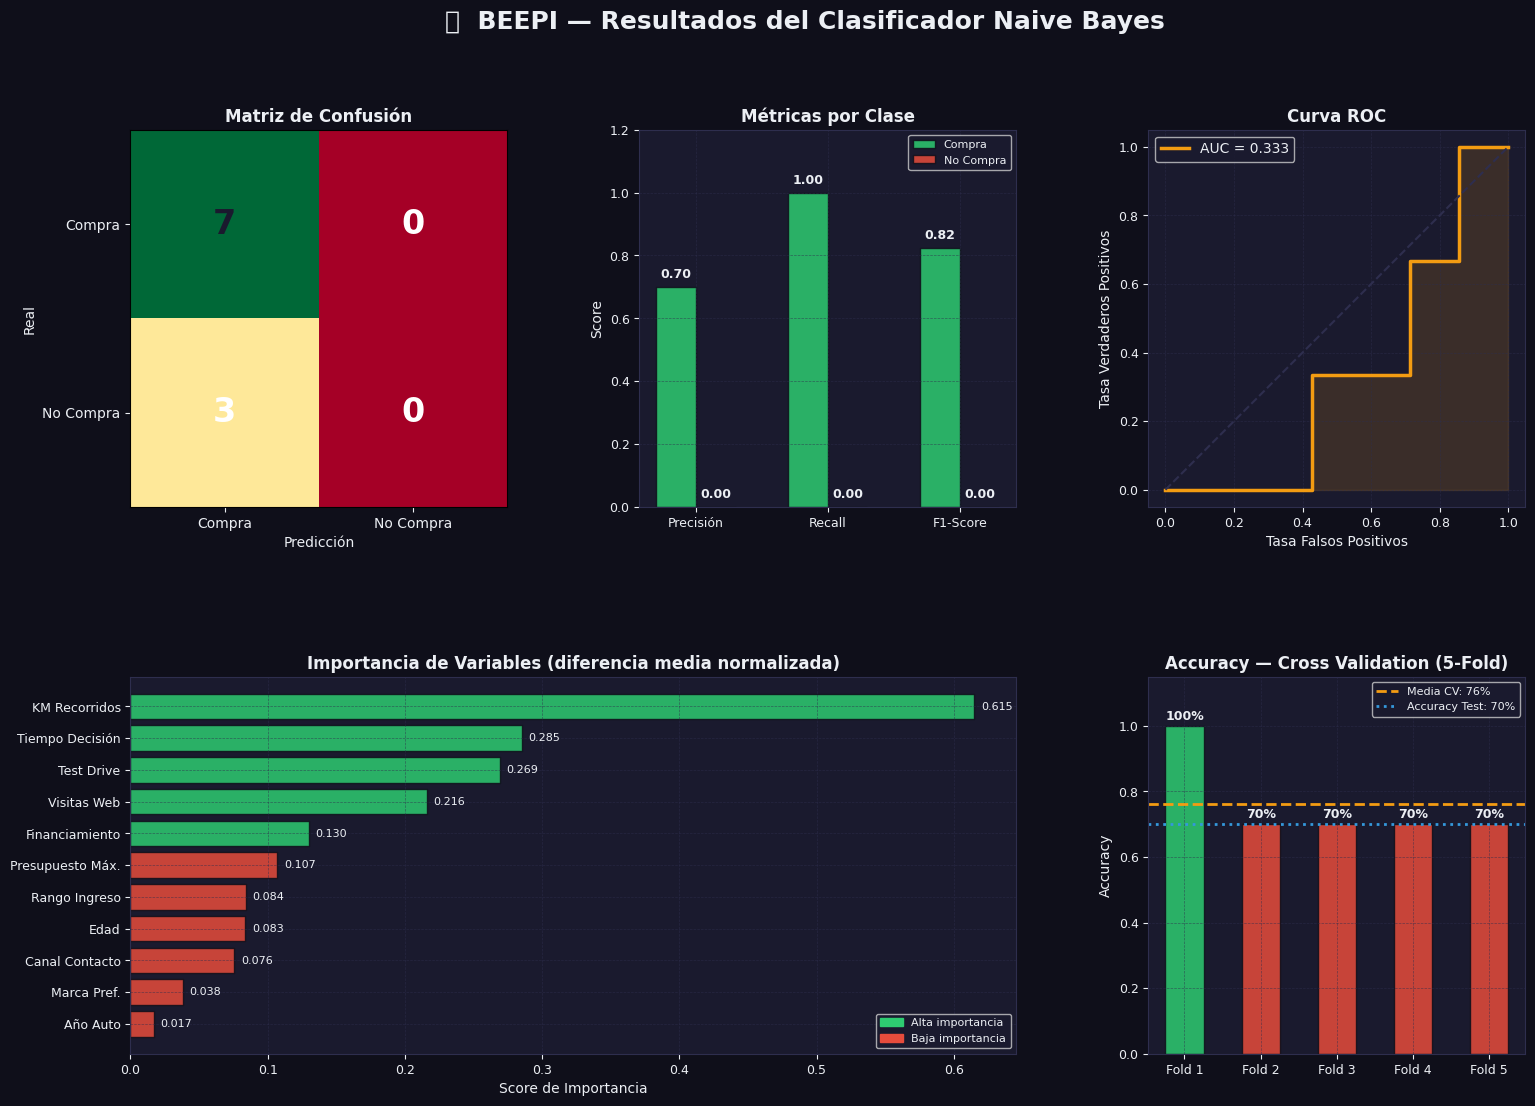

   ✅ grafico2_resultados_naive_bayes.png


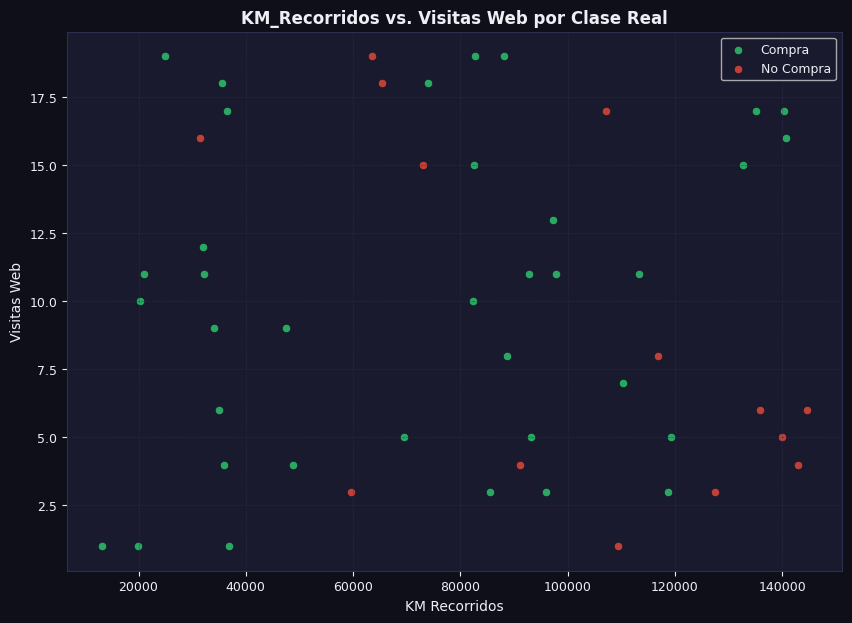

   ✅ grafico_dispersion_pre_naive_bayes.png


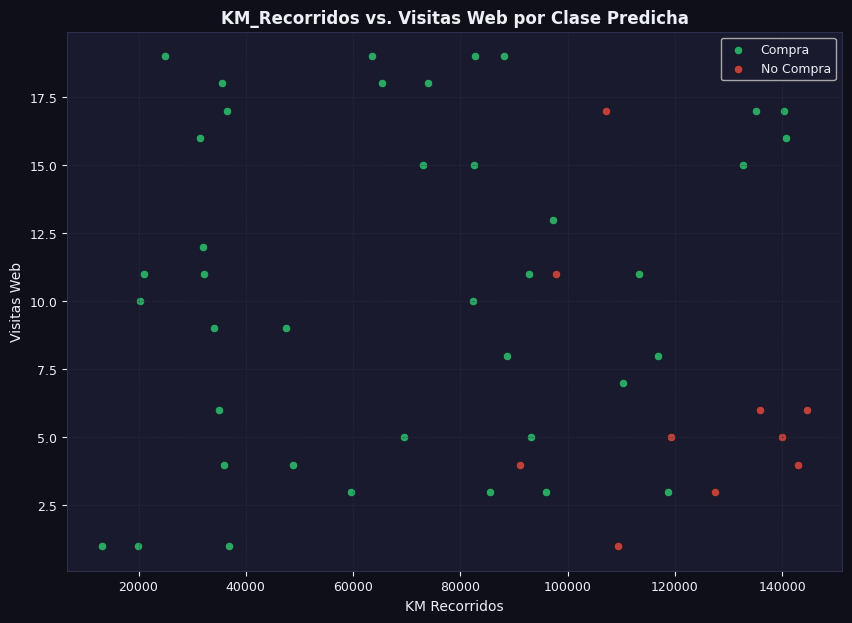

   ✅ grafico_dispersion_post_naive_bayes.png

💾 Exportando predicciones...
   ✅ beepi_predicciones.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Archivos descargados en tu equipo.

🔮 Predicción nuevo cliente...
══════════════════════════════════════════════════
    PREDICCIÓN PARA NUEVO CLIENTE BEEPI
══════════════════════════════════════════════════
  Resultado       : 🟢 Compra
  Prob. Compra    : 98.5%
  Prob. No Compra : 1.5%
══════════════════════════════════════════════════

✅ Script completado exitosamente.


In [9]:
# ══════════════════════════════════════════════════════════════════
#  🚗  BEEPI — Naive Bayes Completo | Predicción de Compra
#  Sube Excel → Preprocesamiento → Modelo → Gráfico 1 + Gráfico 2
# ══════════════════════════════════════════════════════════════════

# ── INSTALACIÓN (solo Google Colab) ───────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "openpyxl", "--quiet"], check=True)

# ── IMPORTS ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc,
    precision_score, recall_score, f1_score
)

print("✅ Librerías importadas correctamente")


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 1 — CARGA DEL DATASET DESDE EXCEL
# ══════════════════════════════════════════════════════════════════
print("\n↗️ Sube el archivo: beepi_dataset_naive_bayes.xlsx")

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename, sheet_name="Dataset")

# Eliminar columna ID si existe
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Validar columnas esperadas
COLUMNAS_ESPERADAS = [
    "Edad", "Rango_Ingreso", "Presupuesto_Max_USD", "Marca_Preferida",
    "Ano_Auto_Interes", "KM_Recorridos", "Visitas_Web",
    "Realizo_Test_Drive", "Solicita_Financiamiento",
    "Canal_Contacto", "Tiempo_Decision", "Clase"
]
faltantes = [c for c in COLUMNAS_ESPERADAS if c not in df.columns]
if faltantes:
    raise ValueError(f"❌ Columnas faltantes en el Excel: {faltantes}")

print(f"\n✅ Dataset cargado correctamente")
print(f"   Archivo      : {filename}")
print(f"   Registros    : {len(df)}")
print(f"   Distribución : {df['Clase'].value_counts().to_dict()}")
df.head(5)


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 2 — PREPROCESAMIENTO
# ══════════════════════════════════════════════════════════════════
print("\n⚙️  Preprocesando variables...")

df_model = df.copy() # FIX: Changed from df.drop(columns=["ID"]).copy() to df.copy()

le = LabelEncoder()
df_model["Clase_enc"] = le.fit_transform(df_model["Clase"])

oe_ing  = OrdinalEncoder(categories=[["< S/2000","S/2000-4000","S/4000-7000","> S/7000"]])
oe_tiem = OrdinalEncoder(categories=[["> 1 mes","2-4 semanas","1-2 semanas","< 1 semana"]])
df_model["Ingreso_enc"] = oe_ing.fit_transform(df_model[["Rango_Ingreso"]])
df_model["Tiempo_enc"]  = oe_tiem.fit_transform(df_model[["Tiempo_Decision"]])

le_marca  = LabelEncoder().fit(df["Marca_Preferida"])
le_canal  = LabelEncoder().fit(df["Canal_Contacto"])
le_test   = LabelEncoder().fit(df["Realizo_Test_Drive"])
le_fin    = LabelEncoder().fit(df["Solicita_Financiamiento"])

df_model["Marca_enc"]  = le_marca.transform(df_model["Marca_Preferida"])
df_model["Canal_enc"]  = le_canal.transform(df_model["Canal_Contacto"])
df_model["Test_enc"]   = le_test.transform(df_model["Realizo_Test_Drive"])
df_model["Fin_enc"]    = le_fin.transform(df_model["Solicita_Financiamiento"])

FEATURES = [
    "Edad","Presupuesto_Max_USD","Ano_Auto_Interes","KM_Recorridos","Visitas_Web",
    "Ingreso_enc","Tiempo_enc","Marca_enc","Canal_enc","Test_enc","Fin_enc"
]
FEAT_LABELS = [
    "Edad","Presupuesto Máx.","Año Auto","KM Recorridos","Visitas Web",
    "Rango Ingreso","Tiempo Decisión","Marca Pref.","Canal Contacto",
    "Test Drive","Financiamiento"
]

X = df_model[FEATURES].values
y = df_model["Clase_enc"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"   Train: {len(X_train)} | Test: {len(X_test)}")


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 3 — ENTRENAMIENTO
# ══════════════════════════════════════════════════════════════════
print("\n🧠 Entrenando Gaussian Naive Bayes...")

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred   = gnb.predict(X_test)
y_proba  = gnb.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(gnb, X, y, cv=5, scoring="accuracy")

# Calculate predictions for the entire dataset
y_all_pred = gnb.predict(X)
y_all_proba = gnb.predict_proba(X)

print(f"   Accuracy Test  : {accuracy:.2%}")
print(f"   CV 5-Fold      : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")
print("\n" + classification_report(y_test, y_pred, target_names=le.classes_))


# ══════════════════════════════════════════════════════════════════
#  PALETA & HELPER
# ══════════════════════════════════════════════════════════════════
C_COMPRA    = "#2ECC71"
C_NO_COMPRA = "#E74C3C"
C_BG        = "#0F0F1A"
C_PANEL     = "#1A1A2E"
C_TEXT      = "#ECEFF4"
C_GRID      = "#2E2E4E"
C_ACCENT    = "#F39C12"
PALETTE     = [C_COMPRA, C_NO_COMPRA]

def beepi_ax(ax):
    ax.set_facecolor(C_PANEL)
    ax.tick_params(colors=C_TEXT, labelsize=9)
    ax.xaxis.label.set_color(C_TEXT)
    ax.yaxis.label.set_color(C_TEXT)
    ax.title.set_color(C_TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(C_GRID)
    ax.grid(color=C_GRID, linestyle="--", linewidth=0.5, alpha=0.6)


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 4 — GRÁFICO 1: COMPORTAMIENTO DEL DATASET
# ══════════════════════════════════════════════════════════════════
print("\n📊 Generando Gráfico 1 — Comportamiento del Dataset...")

fig1 = plt.figure(figsize=(18, 14), facecolor=C_BG)
fig1.suptitle("🚗  BEEPI — Comportamiento del Dataset de Clientes",
              fontsize=18, fontweight="bold", color=C_TEXT, y=0.98)
gs1 = fig1.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# 1. Donut — clase objetivo
ax = fig1.add_subplot(gs1[0, 0])
conteos = df["Clase"].value_counts()
wedges, texts, autotexts = ax.pie(
    conteos, labels=conteos.index, colors=PALETTE,
    autopct="%1.1f%%", startangle=90,
    textprops={"color": C_TEXT, "fontsize": 10},
    wedgeprops={"edgecolor": C_BG, "linewidth": 2, "width": 0.65}
)
[at.set_fontweight("bold") for at in autotexts]
ax.set_facecolor(C_PANEL)
ax.set_title("Clase Objetivo", color=C_TEXT, fontweight="bold", pad=10)

# 2. Histograma edad
ax = fig1.add_subplot(gs1[0, 1])
for cls, color in zip(["Compra","No Compra"], PALETTE):
    ax.hist(df[df["Clase"]==cls]["Edad"], bins=8, alpha=0.75, label=cls, color=color, edgecolor=C_BG)
beepi_ax(ax)
ax.set_title("Distribución de Edad", fontweight="bold")
ax.set_xlabel("Edad"); ax.set_ylabel("Frecuencia")
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 3. Test Drive vs Clase
ax = fig1.add_subplot(gs1[0, 2])
pd.crosstab(df["Realizo_Test_Drive"], df["Clase"]).plot(
    kind="bar", ax=ax, color=PALETTE, edgecolor=C_BG, width=0.6)
beepi_ax(ax)
ax.set_title("Test Drive vs Compra", fontweight="bold")
ax.set_xlabel("Realizó Test Drive"); ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=0)
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 4. Rango Ingreso vs Clase
ax = fig1.add_subplot(gs1[1, 0])
pd.crosstab(df["Rango_Ingreso"], df["Clase"]) \
  .reindex(["< S/2000","S/2000-4000","S/4000-7000","> S/7000"]) \
  .plot(kind="bar", ax=ax, color=PALETTE, edgecolor=C_BG, width=0.65)
beepi_ax(ax)
ax.set_title("Rango Ingreso vs Compra", fontweight="bold")
ax.set_xlabel("Rango Ingreso"); ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=20)
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 5. KM Recorridos — boxplot
ax = fig1.add_subplot(gs1[1, 1])
bp = ax.boxplot(
    [df[df["Clase"]=="Compra"]["KM_Recorridos"], df[df["Clase"]=="No Compra"]["KM_Recorridos"]],
    patch_artist=True, widths=0.5,
    medianprops={"color":"white","linewidth":2},
    whiskerprops={"color":C_TEXT}, capprops={"color":C_TEXT},
    flierprops={"markerfacecolor":C_TEXT,"marker":"o","markersize":4}
)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.8)
beepi_ax(ax)
ax.set_xticklabels(["Compra","No Compra"])
ax.set_title("KM Recorridos por Clase", fontweight="bold")
ax.set_ylabel("Kilómetros")

# 6. Visitas Web
ax = fig1.add_subplot(gs1[1, 2])
for cls, color in zip(["Compra","No Compra"], PALETTE):
    ax.hist(df[df["Clase"]==cls]["Visitas_Web"], bins=8, alpha=0.75, label=cls, color=color, edgecolor=C_BG)
beepi_ax(ax)
ax.set_title("Visitas Web por Clase", fontweight="bold")
ax.set_xlabel("N° Visitas"); ax.set_ylabel("Frecuencia")
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 7. Canal de Contacto
ax = fig1.add_subplot(gs1[2, 0])
pd.crosstab(df["Canal_Contacto"], df["Clase"]).plot(
    kind="barh", ax=ax, color=PALETTE, edgecolor=C_BG, width=0.6)
beepi_ax(ax)
ax.set_title("Canal de Contacto vs Compra", fontweight="bold")
ax.set_xlabel("Cantidad"); ax.set_ylabel("")
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 8. Tiempo de Decisión
ax = fig1.add_subplot(gs1[2, 1])
pd.crosstab(df["Tiempo_Decision"], df["Clase"]) \
  .reindex(["< 1 semana","1-2 semanas","2-4 semanas","> 1 mes"]) \
  .plot(kind="bar", ax=ax, color=PALETTE, edgecolor=C_BG, width=0.65)
beepi_ax(ax)
ax.set_title("Tiempo de Decisión vs Compra", fontweight="bold")
ax.set_xlabel("Tiempo"); ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=20)
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 9. Financiamiento
ax = fig1.add_subplot(gs1[2, 2])
pd.crosstab(df["Solicita_Financiamiento"], df["Clase"]).plot(
    kind="bar", ax=ax, color=PALETTE, edgecolor=C_BG, width=0.55)
beepi_ax(ax)
ax.set_title("Financiamiento vs Compra", fontweight="bold")
ax.set_xlabel("Solicita Financiamiento"); ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=0)
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

plt.savefig("grafico1_comportamiento_dataset.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico1_comportamiento_dataset.png")


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 5 — GRÁFICO 2: RESULTADOS NAIVE BAYES
# ══════════════════════════════════════════════════════════════════
print("\n📊 Generando Gráfico 2 — Resultados Naive Bayes...")

fig2 = plt.figure(figsize=(18, 12), facecolor=C_BG)
fig2.suptitle("🚗  BEEPI — Resultados del Clasificador Naive Bayes",
              fontsize=18, fontweight="bold", color=C_TEXT, y=0.98)
gs2 = fig2.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1. Matriz de Confusión
ax = fig2.add_subplot(gs2[0, 0])
cm = confusion_matrix(y_test, y_pred)
ax.imshow(cm, cmap="RdYlGn", aspect="auto")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(le.classes_, color=C_TEXT)
ax.set_yticklabels(le.classes_, color=C_TEXT)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                fontsize=24, fontweight="bold",
                color="white" if cm[i,j] < cm.max()*0.6 else C_PANEL)
ax.set_facecolor(C_PANEL)
ax.set_xlabel("Predicción", color=C_TEXT)
ax.set_ylabel("Real", color=C_TEXT)
ax.set_title("Matriz de Confusión", color=C_TEXT, fontweight="bold")
ax.tick_params(colors=C_TEXT)

# 2. Métricas por clase
ax = fig2.add_subplot(gs2[0, 1])
metricas = {
    "Precisión": [precision_score(y_test,y_pred,pos_label=0), precision_score(y_test,y_pred,pos_label=1)],
    "Recall":    [recall_score(y_test,y_pred,pos_label=0),    recall_score(y_test,y_pred,pos_label=1)],
    "F1-Score":  [f1_score(y_test,y_pred,pos_label=0),        f1_score(y_test,y_pred,pos_label=1)]
}
x_pos = np.arange(len(metricas))
width = 0.3
for i, (cls, color) in enumerate(zip(le.classes_, PALETTE)):
    vals = [metricas[m][i] for m in metricas]
    bars = ax.bar(x_pos + i*width, vals, width, label=cls, color=color, edgecolor=C_BG, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9, color=C_TEXT, fontweight="bold")
beepi_ax(ax)
ax.set_xticks(x_pos + width/2)
ax.set_xticklabels(metricas.keys())
ax.set_ylim(0, 1.2)
ax.set_title("Métricas por Clase", fontweight="bold")
ax.set_ylabel("Score")
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 3. Curva ROC
ax = fig2.add_subplot(gs2[0, 2])
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color=C_ACCENT, lw=2.5, label=f"AUC = {roc_auc:.3f}")
ax.plot([0,1],[0,1], color=C_GRID, linestyle="--", lw=1.5)
ax.fill_between(fpr, tpr, alpha=0.15, color=C_ACCENT)
beepi_ax(ax)
ax.set_xlabel("Tasa Falsos Positivos")
ax.set_ylabel("Tasa Verdaderos Positivos")
ax.set_title("Curva ROC", fontweight="bold")
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=10)

# 4. Importancia de variables
ax = fig2.add_subplot(gs2[1, 0:2])
feat_importance = np.abs(gnb.theta_[0] - gnb.theta_[1]) / (
    np.sqrt(gnb.var_[0]) + np.sqrt(gnb.var_[1]) + 1e-9
)
sorted_idx   = np.argsort(feat_importance)
colors_bar   = [C_COMPRA if feat_importance[i] > np.median(feat_importance) else C_NO_COMPRA for i in sorted_idx]
bars = ax.barh([FEAT_LABELS[i] for i in sorted_idx], feat_importance[sorted_idx],
               color=colors_bar, edgecolor=C_BG, alpha=0.85)
for bar, val in zip(bars, feat_importance[sorted_idx]):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8, color=C_TEXT)
beepi_ax(ax)
ax.set_title("Importancia de Variables (diferencia media normalizada)", fontweight="bold")
ax.set_xlabel("Score de Importancia")
ax.legend(handles=[
    mpatches.Patch(color=C_COMPRA,    label="Alta importancia"),
    mpatches.Patch(color=C_NO_COMPRA, label="Baja importancia")
], facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)

# 5. Accuracy Cross-Validation
ax = fig2.add_subplot(gs2[1, 2])
ax.set_facecolor(C_PANEL)
for sp in ax.spines.values(): sp.set_edgecolor(C_GRID)
fold_colors = [C_COMPRA if s >= cv_scores.mean() else C_NO_COMPRA for s in cv_scores]
bars_cv = ax.bar([f"Fold {i+1}" for i in range(5)], cv_scores,
                 color=fold_colors, edgecolor=C_BG, alpha=0.85, width=0.5)
for bar, v in zip(bars_cv, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{v:.0%}", ha="center", va="bottom", fontsize=9, color=C_TEXT, fontweight="bold")
ax.axhline(cv_scores.mean(), color=C_ACCENT, linestyle="--", lw=2, label=f"Media CV: {cv_scores.mean():.0%}")
ax.axhline(accuracy, color="#3498DB", linestyle=":", lw=2, label=f"Accuracy Test: {accuracy:.0%}")
ax.set_ylim(0, 1.15)
ax.set_title("Accuracy — Cross Validation (5-Fold)", color=C_TEXT, fontweight="bold")
ax.set_ylabel("Accuracy", color=C_TEXT)
ax.tick_params(colors=C_TEXT, labelsize=9)
ax.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=8)
ax.grid(color=C_GRID, linestyle="--", linewidth=0.5, alpha=0.6)

plt.savefig("grafico2_resultados_naive_bayes.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico2_resultados_naive_bayes.png")

# Generando Gráfico de Dispersión Pre-Naive Bayes...

fig_scatter = plt.figure(figsize=(10, 7), facecolor=C_BG)
ax_scatter = fig_scatter.add_subplot(1, 1, 1)

# Map 'Clase' values to colors from PALETTE
class_colors = dict(zip(df['Clase'].unique(), PALETTE))

for cls, color in class_colors.items():
    subset = df[df['Clase'] == cls]
    ax_scatter.scatter(
        subset['KM_Recorridos'],
        subset['Visitas_Web'],
        color=color,
        label=cls,
        alpha=0.8,
        edgecolors=C_BG,
        linewidths=0.5
    )

beepi_ax(ax_scatter)

ax_scatter.set_title("KM_Recorridos vs. Visitas Web por Clase Real", fontweight="bold")
ax_scatter.set_xlabel("KM Recorridos")
ax_scatter.set_ylabel("Visitas Web")
ax_scatter.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=9)

plt.savefig("grafico_dispersion_pre_naive_bayes.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico_dispersion_pre_naive_bayes.png")

# Generando Gráfico de Dispersión Post-Naive Bayes...

fig_scatter_post = plt.figure(figsize=(10, 7), facecolor=C_BG)
ax_scatter_post = fig_scatter_post.add_subplot(1, 1, 1)

# Transform numerical predictions back to original class labels
df_model['Prediccion_Clase'] = le.inverse_transform(y_all_pred)

# Map predicted 'Clase' values to colors from PALETTE
# Assuming le.classes_ provides the order ['Compra', 'No Compra'] or similar consistent order
# And PALETTE is [C_COMPRA, C_NO_COMPRA]
# We need to ensure correct mapping. Let's create a dynamic mapping.
predicted_classes_unique = np.unique(df_model['Prediccion_Clase'])
class_to_color_map = {}
for i, cls_name in enumerate(le.classes_):
    if cls_name in predicted_classes_unique:
        class_to_color_map[cls_name] = PALETTE[i % len(PALETTE)]

for cls_name, color in class_to_color_map.items():
    subset = df_model[df_model['Prediccion_Clase'] == cls_name]
    ax_scatter_post.scatter(
        subset['KM_Recorridos'],
        subset['Visitas_Web'],
        color=color,
        label=cls_name,
        alpha=0.8,
        edgecolors=C_BG,
        linewidths=0.5
    )

beepi_ax(ax_scatter_post)

ax_scatter_post.set_title("KM_Recorridos vs. Visitas Web por Clase Predicha", fontweight="bold")
ax_scatter_post.set_xlabel("KM Recorridos")
ax_scatter_post.set_ylabel("Visitas Web")
ax_scatter_post.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=9)

plt.savefig("grafico_dispersion_post_naive_bayes.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico_dispersion_post_naive_bayes.png")


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 6 — EXPORTAR PREDICCIONES + DESCARGA (Colab)
# ══════════════════════════════════════════════════════════════════
print("\n💾 Exportando predicciones...")

df_res = df.copy().reset_index(drop=True)
X_all    = df_model[FEATURES].values
y_all_pred  = gnb.predict(X_all)
y_all_proba = gnb.predict_proba(X_all)

df_res["Prediccion"]    = le.inverse_transform(y_all_pred)
df_res["Prob_Compra"]   = y_all_proba[:, 0].round(3)
df_res["Prob_NoCompra"] = y_all_proba[:, 1].round(3)
df_res["Correcto"]      = (df_res["Clase"] == df_res["Prediccion"]).map({True: "✅", False: "❌"})
df_res.to_excel("beepi_predicciones.xlsx", index=False)
print("   ✅ beepi_predicciones.xlsx")

try:
    from google.colab import files
    files.download("grafico1_comportamiento_dataset.png")
    files.download("grafico2_resultados_naive_bayes.png")
    files.download("grafico_dispersion_pre_naive_bayes.png") # Added this line
    files.download("grafico_dispersion_post_naive_bayes.png") # Added this line
    files.download("beepi_predicciones.xlsx")
    print("\n🎉 Archivos descargados en tu equipo.")
except ImportError:
    print("\n💡 Ejecución local — archivos guardados en el directorio actual.")


# ══════════════════════════════════════════════════════════════════
#  BLOQUE 7 — PREDICCIÓN DE NUEVO CLIENTE (editable)
# ══════════════════════════════════════════════════════════════════
print("\n🔮 Predicción nuevo cliente...")

nuevo_cliente = {
    "Edad"                   : 35,
    "Rango_Ingreso"          : "S/4000-7000",   # < S/2000 | S/2000-4000 | S/4000-7000 | > S/7000
    "Presupuesto_Max_USD"    : 18000,
    "Marca_Preferida"        : "Toyota",         # Toyota | Hyundai | Kia | Nissan | Chevrolet
    "Ano_Auto_Interes"      : 2020,
    "KM_Recorridos"          : 45000,
    "Visitas_Web"            : 8,
    "Realizo_Test_Drive"     : "Sí",             # Sí | No
    "Solicita_Financiamiento": "Sí",             # Sí | No
    "Canal_Contacto"         : "Web",            # Web | App | Referido | Redes Sociales
    "Tiempo_Decision"        : "1-2 semanas",    # < 1 semana | 1-2 semanas | 2-4 semanas | > 1 mes
}

nc = nuevo_cliente
X_nuevo = np.array([[
    nc["Edad"],
    nc["Presupuesto_Max_USD"],
    nc["Ano_Auto_Interes"],
    nc["KM_Recorridos"],
    nc["Visitas_Web"],
    oe_ing.transform([[nc["Rango_Ingreso"]]])[0][0],
    oe_tiem.transform([[nc["Tiempo_Decision"]]])[0][0],
    le_marca.transform([nc["Marca_Preferida"]])[0],
    le_canal.transform([nc["Canal_Contacto"]])[0],
    le_test.transform([nc["Realizo_Test_Drive"]])[0],
    le_fin.transform([nc["Solicita_Financiamiento"]])[0],
]])

pred  = gnb.predict(X_nuevo)[0]
proba = gnb.predict_proba(X_nuevo)[0]
clase = le.inverse_transform([pred])[0]
emoji = "🟢" if clase == "Compra" else "🟥"

print("═"*50)
print("    PREDICCIÓN PARA NUEVO CLIENTE BEEPI")
print("═"*50)
print(f"  Resultado       : {emoji} {clase}")
print(f"  Prob. Compra    : {proba[0]:.1%}")
print(f"  Prob. No Compra : {proba[1]:.1%}")
print("═"*50)
print("\n✅ Script completado exitosamente.")


## 🚀 Tutorial BEEPI: Predicción de Compra con Naive Bayes

¡Bienvenido a este tutorial! Aquí desglosaremos un script completo que utiliza el algoritmo de Naive Bayes para predecir si un cliente de BEEPI realizará una compra. Aprenderemos desde la carga de datos hasta la visualización y la predicción para nuevos clientes.

---

### **Paso 1: Preparación del Entorno**

Antes de empezar a trabajar con los datos, necesitamos asegurarnos de que tenemos todas las herramientas necesarias instaladas y listas.

#### 📦 1.1 Instalación de Librerías

Los scripts de Python a menudo dependen de librerías externas que añaden funcionalidades específicas. En este caso, necesitamos `openpyxl` para que la librería `pandas` pueda leer archivos Excel. El comando `subprocess.run` ejecuta una instrucción de terminal directamente desde Python.

```python
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "openpyxl", "--quiet"], check=True)
```

*   `subprocess.run`: Ejecuta comandos del sistema operativo.
*   `sys.executable`: Asegura que `pip` se ejecute con el mismo intérprete de Python que está usando el notebook.
*   `-m pip install openpyxl`: Comando para instalar la librería `openpyxl`.
*   `--quiet`: Hace que la instalación sea silenciosa, sin mostrar mensajes en pantalla.
*   `check=True`: Si la instalación falla, se generará un error, lo cual es útil para detectar problemas.

#### 📚 1.2 Importación de Librerías

Una vez instaladas, debemos "importar" estas librerías para poder usarlas en nuestro código. Piensa en esto como abrir tu caja de herramientas y sacar las herramientas que vas a necesitar.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc,
    precision_score, recall_score, f1_score
)

print("✅ Librerías importadas correctamente")
```

*   `pandas as pd`: Para trabajar con DataFrames (tablas de datos). `pd` es un alias común.
*   `numpy as np`: Para cálculos numéricos avanzados, especialmente con arrays.
*   `matplotlib.pyplot as plt`: Para crear gráficos y visualizaciones. `plt` es el alias usual.
*   `matplotlib.patches as mpatches`: Para elementos gráficos más específicos, como parches en leyendas.
*   `warnings.filterwarnings("ignore")`: Desactiva la visualización de advertencias, lo cual es útil para mantener el output limpio durante el desarrollo.
*   **De `sklearn` (Scikit-learn)**: Esta es una librería clave para Machine Learning.
    *   `GaussianNB`: El modelo de clasificador Naive Bayes Gaussiano.
    *   `LabelEncoder`, `OrdinalEncoder`: Herramientas para convertir texto en números (codificación) para que los modelos puedan procesarlos.
    *   `train_test_split`, `cross_val_score`: Funciones para dividir los datos y evaluar el modelo de forma robusta.
    *   `classification_report`, `confusion_matrix`, `accuracy_score`, `roc_curve`, `auc`, `precision_score`, `recall_score`, `f1_score`: Métricas para evaluar el rendimiento de nuestro modelo de clasificación.

---

### **Paso 2: Carga y Preparación Inicial del Dataset**

En este paso, tomaremos nuestros datos en formato Excel y los cargaremos en Python, haciendo una primera limpieza y verificación.

#### 💾 2.1 Carga del Dataset desde Excel

Se te pedirá que subas un archivo Excel. Una vez subido, lo leeremos y haremos una verificación básica de sus columnas.

```python
print("\n↗️ Sube el archivo: beepi_dataset_naive_bayes.xlsx")

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename, sheet_name="Dataset")

# Eliminar columna ID si existe
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

# Validar columnas esperadas
COLUMNAS_ESPERADAS = [
    "Edad", "Rango_Ingreso", "Presupuesto_Max_USD", "Marca_Preferida",
    "Ano_Auto_Interes", "KM_Recorridos", "Visitas_Web",
    "Realizo_Test_Drive", "Solicita_Financiamiento",
    "Canal_Contacto", "Tiempo_Decision", "Clase"
]
faltantes = [c for c in COLUMNAS_ESPERADAS if c not in df.columns]
if faltantes:
    raise ValueError(f"❌ Columnas faltantes en el Excel: {faltantes}")

print(f"\n✅ Dataset cargado correctamente")
print(f"   Archivo      : {filename}")
print(f"   Registros    : {len(df)}")
print(f"   Distribución : {df['Clase'].value_counts().to_dict()}")
df.head(5)
```

*   `files.upload()`: Esta función, específica de Google Colab, abre un cuadro de diálogo para que selecciones y subas un archivo desde tu computadora.
*   `filename = list(uploaded.keys())[0]`: Una vez subido, `uploaded` contiene el archivo. Extraemos el nombre del archivo.
*   `pd.read_excel()`: Lee el archivo Excel y lo convierte en un DataFrame de pandas llamado `df`. Especificamos `sheet_name="Dataset"` por si el Excel tuviera varias hojas.
*   `if "ID" in df.columns: df = df.drop(columns=["ID"])`: Verifica si existe una columna llamada 'ID' y, si es así, la elimina. Las IDs rara vez son útiles para el modelado.
*   `COLUMNAS_ESPERADAS`: Una lista con los nombres de las columnas que nuestro script espera encontrar. Esto es crucial para evitar errores si el archivo Excel tiene una estructura diferente.
*   `faltantes`: Compara las columnas presentes en `df` con las `COLUMNAS_ESPERADAS` y lista las que faltan.
*   `raise ValueError`: Si faltan columnas, el script se detiene y nos informa exactamente cuáles son, lo cual es muy útil para depurar.
*   Los `print` finales muestran un resumen de la carga: nombre del archivo, número de registros y la distribución de la variable objetivo 'Clase' (cuántos clientes compran y cuántos no).

---

### **Paso 3: Preprocesamiento de Datos**

Los modelos de Machine Learning no siempre entienden los datos tal como los leemos. A menudo, necesitamos transformar las variables de texto a números. Este es el trabajo del preprocesamiento.

#### ⚙️ 3.1 Transformación de Variables para el Modelo

Aquí, convertimos las variables categóricas (como el rango de ingresos o la marca preferida) en formatos numéricos que el modelo pueda usar. También separamos nuestras características (X) de nuestra variable objetivo (y).

```python
print("\n⚙️  Preprocesando variables...")

df_model = df.copy() # FIX: Changed from df.drop(columns=["ID"]).copy() to df.copy()

le = LabelEncoder()
df_model["Clase_enc"] = le.fit_transform(df_model["Clase"])

oe_ing  = OrdinalEncoder(categories=[["< S/2000","S/2000-4000","S/4000-7000","> S/7000"]])
oe_tiem = OrdinalEncoder(categories=[["> 1 mes","2-4 semanas","1-2 semanas","< 1 semana"]])
df_model["Ingreso_enc"] = oe_ing.fit_transform(df_model[["Rango_Ingreso"]])
df_model["Tiempo_enc"]  = oe_tiem.fit_transform(df_model[["Tiempo_Decision"]])

le_marca  = LabelEncoder().fit(df["Marca_Preferida"])
le_canal  = LabelEncoder().fit(df["Canal_Contacto"])
le_test   = LabelEncoder().fit(df["Realizo_Test_Drive"])
le_fin    = LabelEncoder().fit(df["Solicita_Financiamiento"])

df_model["Marca_enc"]  = le_marca.transform(df_model["Marca_Preferida"])
df_model["Canal_enc"]  = le_canal.transform(df_model["Canal_Contacto"])
df_model["Test_enc"]   = le_test.transform(df_model["Realizo_Test_Drive"])
df_model["Fin_enc"]    = le_fin.transform(df_model["Solicita_Financiamiento"])

FEATURES = [
    "Edad","Presupuesto_Max_USD","Ano_Auto_Interes","KM_Recorridos","Visitas_Web",
    "Ingreso_enc","Tiempo_enc","Marca_enc","Canal_enc","Test_enc","Fin_enc"
]
FEAT_LABELS = [
    "Edad","Presupuesto Máx.","Año Auto","KM Recorridos","Visitas Web",
    "Rango Ingreso","Tiempo Decisión","Marca Pref.","Canal Contacto",
    "Test Drive","Financiamiento"
]

X = df_model[FEATURES].values
y = df_model["Clase_enc"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"   Train: {len(X_train)} | Test: {len(X_test)}")
```

*   `df_model = df.copy()`: Creamos una copia del DataFrame original para no modificarlo directamente. Esto es una buena práctica.
*   `LabelEncoder()`: Se usa para variables categóricas nominales (sin orden). Asigna un número único a cada categoría (ej: 'Compra' -> 0, 'No Compra' -> 1). Se usa para la variable objetivo `Clase` y otras como `Marca_Preferida`.
    *   `le.fit_transform(df_model["Clase"])`: `fit` aprende las categorías únicas y `transform` las convierte en números.
*   `OrdinalEncoder()`: Se usa para variables categóricas ordinales (con un orden intrínseco). Le decimos explícitamente el orden de las categorías.
    *   `oe_ing = OrdinalEncoder(categories=[["< S/2000","S/2000-4000","S/4000-7000","> S/7000"]])`: Se define el orden para `Rango_Ingreso`.
    *   `oe_tiem = OrdinalEncoder(categories=[["> 1 mes","2-4 semanas","1-2 semanas","< 1 semana"]])`: Se define el orden para `Tiempo_Decision`.
*   `FEATURES` y `FEAT_LABELS`: Listas que definen las columnas que usaremos como entradas para el modelo (`FEATURES`) y sus nombres más amigables para los gráficos (`FEAT_LABELS`).
*   `X = df_model[FEATURES].values`: `X` contendrá nuestras características de entrada, ya codificadas, listas para el modelo.
*   `y = df_model["Clase_enc"].values`: `y` contendrá nuestra variable objetivo, también codificada numéricamente.
*   `train_test_split()`: Divide nuestros datos en dos partes: `X_train`, `y_train` para entrenar el modelo, y `X_test`, `y_test` para probarlo. Esto asegura que el modelo se evalúe con datos que no ha visto antes.
    *   `test_size=0.20`: El 20% de los datos se usará para pruebas.
    *   `random_state=42`: Asegura que la división sea la misma cada vez que ejecutemos el script, haciendo los resultados reproducibles.
    *   `stratify=y`: Mantiene la misma proporción de clases en los conjuntos de entrenamiento y prueba que en el dataset original. Esto es importante para clases desbalanceadas.

---

### **Paso 4: Entrenamiento del Modelo de Naive Bayes**

Aquí es donde la magia de Machine Learning sucede. Entrenamos un modelo para que aprenda patrones en los datos y pueda hacer predicciones.

#### 🧠 4.1 Construcción y Evaluación del Modelo Naive Bayes

Usaremos el clasificador Naive Bayes Gaussiano, que es adecuado para características numéricas que siguen una distribución gaussiana (en forma de campana).

```python
print("\n🧠 Entrenando Gaussian Naive Bayes...")

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred   = gnb.predict(X_test)
y_proba  = gnb.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
cv_scores = cross_val_score(gnb, X, y, cv=5, scoring="accuracy")

# Calculate predictions for the entire dataset
y_all_pred = gnb.predict(X)
y_all_proba = gnb.predict_proba(X)

print(f"   Accuracy Test  : {accuracy:.2%}")
print(f"   CV 5-Fold      : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")
print("\n" + classification_report(y_test, y_pred, target_names=le.classes_))
```

*   `gnb = GaussianNB()`: Creamos una instancia de nuestro modelo Naive Bayes Gaussiano.
*   `gnb.fit(X_train, y_train)`: Entrenamos el modelo. Le mostramos los datos de entrenamiento (`X_train`) y las respuestas correctas (`y_train`) para que aprenda a relacionarlos.
*   `y_pred = gnb.predict(X_test)`: Una vez entrenado, el modelo hace predicciones sobre los datos de prueba (`X_test`).
*   `y_proba = gnb.predict_proba(X_test)`: Obtiene la probabilidad de que cada predicción pertenezca a cada clase.
*   `accuracy = accuracy_score(y_test, y_pred)`: Calcula la precisión del modelo en los datos de prueba. Es el porcentaje de predicciones correctas.
*   `cross_val_score(gnb, X, y, cv=5, scoring="accuracy")`: Realiza una validación cruzada. Esto divide el dataset en 5 partes (folds), entrena el modelo 5 veces (cada vez con un fold diferente como prueba y el resto como entrenamiento) y promedia los resultados. Da una medida más robusta del rendimiento del modelo.
*   `y_all_pred = gnb.predict(X)` y `y_all_proba = gnb.predict_proba(X)`: Genera predicciones para **todo el dataset original**, no solo el conjunto de prueba. Esto es útil para los gráficos posteriores.
*   `classification_report()`: Muestra un resumen detallado de las métricas clave del modelo: precisión, recall (sensibilidad), f1-score y soporte para cada clase. Explica qué tan bien clasifica el modelo cada tipo de cliente.

---

### **Paso 5: Visualización de Datos y Resultados**

Los gráficos nos ayudan a entender nuestros datos y a evaluar visualmente el rendimiento del modelo.

#### 🎨 5.1 Estilo de Gráficos (Paleta y Helper)

Para que nuestros gráficos se vean bien y sean consistentes, definimos una paleta de colores y una función que aplica un estilo uniforme a los ejes de Matplotlib.

```python
C_COMPRA    = "#2ECC71"
C_NO_COMPRA = "#E74C3C"
C_BG        = "#0F0F1A"
C_PANEL     = "#1A1A2E"
C_TEXT      = "#ECEFF4"
C_GRID      = "#2E2E4E"
C_ACCENT    = "#F39C12"
PALETTE     = [C_COMPRA, C_NO_COMPRA]

def beepi_ax(ax):
    ax.set_facecolor(C_PANEL)
    ax.tick_params(colors=C_TEXT, labelsize=9)
    ax.xaxis.label.set_color(C_TEXT)
    ax.yaxis.label.set_color(C_TEXT)
    ax.title.set_color(C_TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(C_GRID)
    ax.grid(color=C_GRID, linestyle="--", linewidth=0.5, alpha=0.6)
```

*   `C_COMPRA`, `C_NO_COMPRA`, etc.: Definición de colores hexadecimales para elementos del gráfico. Esto permite una personalización visual fácil.
*   `PALETTE`: Una lista de los colores principales que usaremos (compra y no compra).
*   `beepi_ax(ax)`: Una función que toma un objeto de eje de Matplotlib (`ax`) y le aplica un estilo predefinido: color de fondo del panel, color y tamaño de la fuente de los ticks y etiquetas, color del título, color de los bordes del gráfico y una cuadrícula tenue. Esto garantiza una estética unificada.

#### 📊 5.2 BLOQUE 4 — Gráfico 1: Comportamiento del Dataset

Este conjunto de gráficos nos ayuda a explorar y entender la distribución y relación de las variables en nuestro dataset original, antes de adentrarnos en las predicciones del modelo.

```python
print("\n📊 Generando Gráfico 1 — Comportamiento del Dataset...")

fig1 = plt.figure(figsize=(18, 14), facecolor=C_BG)
fig1.suptitle("🚗  BEEPI — Comportamiento del Dataset de Clientes",
              fontsize=18, fontweight="bold", color=C_TEXT, y=0.98)
gs1 = fig1.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ... (código para los 9 subgráficos como donut, histogramas, barras, boxplot) ...

plt.savefig("grafico1_comportamiento_dataset.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico1_comportamiento_dataset.png")
```

*   `fig1 = plt.figure(...)`: Crea la figura principal para nuestro conjunto de gráficos, definiendo su tamaño y color de fondo.
*   `fig1.suptitle(...)`: Añade un título general a toda la figura.
*   `gs1 = fig1.add_gridspec(3, 3, ...)`: Organiza la figura en una cuadrícula de 3 filas por 3 columnas para colocar varios subgráficos.
*   **Ejemplos de Subgráficos:**
    *   **Donut - clase objetivo**: Muestra la proporción de clientes que 'Compran' y 'No Compran'.
    *   **Histograma edad**: Muestra la distribución de edad, diferenciando entre compradores y no compradores.
    *   **Test Drive vs Clase**: Gráfico de barras que compara si realizar un test drive influye en la compra.
    *   **Rango Ingreso vs Clase**: Gráfico de barras que analiza cómo el rango de ingresos se relaciona con la decisión de compra.
    *   **KM Recorridos — boxplot**: Muestra la distribución de kilómetros recorridos por clase de compra, útil para identificar diferencias en la dispersión.
    *   **Visitas Web**: Histograma similar al de edad, para el número de visitas a la web.
    *   **Canal de Contacto**, **Tiempo de Decisión**, **Financiamiento**: Gráficos de barras que exploran la relación de estas variables con la clase de compra.
*   `beepi_ax(ax)`: Se aplica a cada subgráfico para darle el estilo predefinido.
*   `plt.savefig(...)`: Guarda la figura completa como un archivo PNG con alta resolución (`dpi=150`).
*   `plt.show()`: Muestra el gráfico en la salida del notebook.

#### 📊 5.3 BLOQUE 5 — Gráfico 2: Resultados Naive Bayes

Estos gráficos se centran en el rendimiento del modelo Naive Bayes, dándonos una visión profunda de cómo está clasificando y dónde puede mejorar.

```python
print("\n📊 Generando Gráfico 2 — Resultados Naive Bayes...")

fig2 = plt.figure(figsize=(18, 12), facecolor=C_BG)
fig2.suptitle("🚗  BEEPI — Resultados del Clasificador Naive Bayes",
              fontsize=18, fontweight="bold", color=C_TEXT, y=0.98)
gs2 = fig2.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ... (código para los 5 subgráficos como Matriz de Confusión, Métricas por clase, Curva ROC, Importancia de variables, Accuracy Cross-Validation) ...

plt.savefig("grafico2_resultados_naive_bayes.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico2_resultados_naive_bayes.png")
```

*   Similar al Gráfico 1, crea una figura y una cuadrícula para organizar los subgráficos de resultados.
*   **Ejemplos de Subgráficos:**
    *   **Matriz de Confusión**: Muestra cuántas predicciones fueron correctas e incorrectas para cada clase. Es fundamental para entender los *falsos positivos* y *falsos negativos*.
    *   **Métricas por clase**: Gráficos de barras que visualizan la precisión, recall y F1-score para cada clase, facilitando la comparación.
    *   **Curva ROC (Receiver Operating Characteristic)**: Una gráfica que muestra el rendimiento del modelo en todos los umbrales de clasificación. El Área Bajo la Curva (AUC) es una métrica clave: cuanto más cerca esté de 1, mejor es el modelo.
    *   **Importancia de variables**: Este gráfico es crucial para entender qué características son las más influyentes en las decisiones del modelo (ver explicación detallada más abajo).
    *   **Accuracy Cross-Validation**: Muestra la precisión del modelo en cada fold de la validación cruzada y la compara con la precisión en el conjunto de prueba. Nos da confianza en la estabilidad del modelo.
*   `plt.savefig(...)` y `plt.show()`: Guardan y muestran la figura de resultados.

---

### **Paso 6: Gráficos de Dispersión Adicionales**

Para visualizar mejor cómo el modelo intenta separar las clases, generamos gráficos de dispersión que muestran las variables más importantes coloreadas por la clase real y luego por la clase predicha.

#### 📈 6.1 Gráfico de Dispersión Pre-Naive Bayes

Este gráfico muestra cómo se distribuyen dos características importantes (`KM_Recorridos` y `Visitas_Web`) en el dataset original, coloreadas según la clase real de cada cliente.

```python
# Generando Gráfico de Dispersión Pre-Naive Bayes...

fig_scatter = plt.figure(figsize=(10, 7), facecolor=C_BG)
ax_scatter = fig_scatter.add_subplot(1, 1, 1)

# Map 'Clase' values to colors from PALETTE
class_colors = dict(zip(df['Clase'].unique(), PALETTE))

for cls, color in class_colors.items():
    subset = df[df['Clase'] == cls]
    ax_scatter.scatter(
        subset['KM_Recorridos'],
        subset['Visitas_Web'],
        color=color,
        label=cls,
        alpha=0.8,
        edgecolors=C_BG,
        linewidths=0.5
    )

beepi_ax(ax_scatter)

ax_scatter.set_title("KM_Recorridos vs. Visitas Web por Clase Real", fontweight="bold")
ax_scatter.set_xlabel("KM Recorridos")
ax_scatter.set_ylabel("Visitas Web")
ax_scatter.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=9)

plt.savefig("grafico_dispersion_pre_naive_bayes.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico_dispersion_pre_naive_bayes.png")
```

*   Se crea un gráfico de dispersión (`scatter plot`) utilizando `KM_Recorridos` en el eje X y `Visitas_Web` en el eje Y.
*   Los puntos se colorean según la `Clase` real del cliente (Compra o No Compra), usando nuestra `PALETTE` predefinida. Esto nos permite ver la separación natural de las clases en estas dos dimensiones.
*   `beepi_ax(ax_scatter)`: Aplica nuestro estilo visual al gráfico.
*   Se guarda y muestra el gráfico.

#### 📈 6.2 Gráfico de Dispersión Post-Naive Bayes

Similar al anterior, pero esta vez los puntos se colorean según la clase *predicha* por nuestro modelo de Naive Bayes. Esto nos ayuda a entender cómo el modelo "ve" y clasifica las clases en estas dos dimensiones.

```python
# Generando Gráfico de Dispersión Post-Naive Bayes...

fig_scatter_post = plt.figure(figsize=(10, 7), facecolor=C_BG)
ax_scatter_post = fig_scatter_post.add_subplot(1, 1, 1)

# Transform numerical predictions back to original class labels
df_model['Prediccion_Clase'] = le.inverse_transform(y_all_pred)

# Map predicted 'Clase' values to colors from PALETTE
# Assuming le.classes_ provides the order ['Compra', 'No Compra'] or similar consistent order
# And PALETTE is [C_COMPRA, C_NO_COMPRA]
# We need to ensure correct mapping. Let's create a dynamic mapping.
predicted_classes_unique = np.unique(df_model['Prediccion_Clase'])
class_to_color_map = {}
for i, cls_name in enumerate(le.classes_):
    if cls_name in predicted_classes_unique:
        class_to_color_map[cls_name] = PALETTE[i % len(PALETTE)]

for cls_name, color in class_to_color_map.items():
    subset = df_model[df_model['Prediccion_Clase'] == cls_name]
    ax_scatter_post.scatter(
        subset['KM_Recorridos'],
        subset['Visitas_Web'],
        color=color,
        label=cls_name,
        alpha=0.8,
        edgecolors=C_BG,
        linewidths=0.5
    )

beepi_ax(ax_scatter_post)

ax_scatter_post.set_title("KM_Recorridos vs. Visitas Web por Clase Predicha", fontweight="bold")
ax_scatter_post.set_xlabel("KM Recorridos")
ax_scatter_post.set_ylabel("Visitas Web")
ax_scatter_post.legend(facecolor=C_PANEL, labelcolor=C_TEXT, fontsize=9)

plt.savefig("grafico_dispersion_post_naive_bayes.png", dpi=150, bbox_inches="tight", facecolor=C_BG)
plt.show()
print("   ✅ grafico_dispersion_post_naive_bayes.png")
```

*   `df_model['Prediccion_Clase'] = le.inverse_transform(y_all_pred)`: Convierte las predicciones numéricas del modelo (`y_all_pred`) de nuevo a sus etiquetas originales ('Compra'/'No Compra') para que sean comprensibles.
*   Se genera un gráfico de dispersión, pero esta vez usando la `Prediccion_Clase` para colorear los puntos. Al comparar este gráfico con el pre-Naive Bayes, podemos ver visualmente cómo el modelo ha intentado separar y clasificar los datos.

---

### **Paso 7: Exportación de Resultados y Predicción de Nuevos Clientes**

Finalmente, guardamos nuestras predicciones y demostramos cómo usar el modelo para predecir el comportamiento de un cliente nuevo y desconocido.

#### 💾 7.1 Exportar Predicciones y Descarga

Guardamos las predicciones del modelo para todo el dataset en un archivo Excel, añadiendo información sobre la probabilidad y si la predicción fue correcta. También facilitamos la descarga de todos los gráficos generados.

```python
print("\n💾 Exportando predicciones...")

df_res = df.copy().reset_index(drop=True)
X_all    = df_model[FEATURES].values
y_all_pred  = gnb.predict(X_all)
y_all_proba = gnb.predict_proba(X_all)

df_res["Prediccion"]    = le.inverse_transform(y_all_pred)
df_res["Prob_Compra"]   = y_all_proba[:, 0].round(3)
df_res["Prob_NoCompra"] = y_all_proba[:, 1].round(3)
df_res["Correcto"]      = (df_res["Clase"] == df_res["Prediccion"]).map({True: "✅", False: "❌"})
df_res.to_excel("beepi_predicciones.xlsx", index=False)
print("   ✅ beepi_predicciones.xlsx")

try:
    from google.colab import files
    files.download("grafico1_comportamiento_dataset.png")
    files.download("grafico2_resultados_naive_bayes.png")
    files.download("grafico_dispersion_pre_naive_bayes.png") # Added this line
    files.download("grafico_dispersion_post_naive_bayes.png") # Added this line
    files.download("beepi_predicciones.xlsx")
    print("\n🎉 Archivos descargados en tu equipo.")
except ImportError:
    print("\n💡 Ejecución local — archivos guardados en el directorio actual.")
```

*   `df_res = df.copy().reset_index(drop=True)`: Crea un nuevo DataFrame para los resultados, asegurándose de que el índice sea numérico y consecutivo.
*   `df_res["Prediccion"]`, `df_res["Prob_Compra"]`, `df_res["Prob_NoCompra"]`: Añade al DataFrame las predicciones, las probabilidades de cada clase y una columna que indica si la predicción del modelo fue igual a la clase real.
*   `df_res.to_excel(...)`: Guarda este DataFrame de resultados en un archivo Excel llamado `beepi_predicciones.xlsx`.
*   `try...except ImportError`: Esta estructura intenta descargar los archivos generados si el script se ejecuta en Google Colab. Si no es Colab (por ejemplo, en tu máquina local), simplemente te informará que los archivos están guardados en el directorio actual.

#### 🔮 7.2 Predicción de Nuevo Cliente (editable)

Una de las aplicaciones más interesantes de un modelo es poder usarlo con nuevos datos. Aquí te mostramos cómo hacer una predicción para un cliente que el modelo nunca ha visto.

```python
print("\n🔮 Predicción nuevo cliente...")

nuevo_cliente = {
    "Edad"                   : 35,
    "Rango_Ingreso"          : "S/4000-7000",
    "Presupuesto_Max_USD"    : 18000,
    "Marca_Preferida"        : "Toyota",
    "Ano_Auto_Interes"      : 2020,
    "KM_Recorridos"          : 45000,
    "Visitas_Web"            : 8,
    "Realizo_Test_Drive"     : "Sí",
    "Solicita_Financiamiento": "Sí",
    "Canal_Contacto"         : "Web",
    "Tiempo_Decision"        : "1-2 semanas",
}

nc = nuevo_cliente
X_nuevo = np.array([[
    nc["Edad"],
    nc["Presupuesto_Max_USD"],
    nc["Ano_Auto_Interes"],
    nc["KM_Recorridos"],
    nc["Visitas_Web"],
    oe_ing.transform([[nc["Rango_Ingreso"]]])[0][0],
    oe_tiem.transform([[nc["Tiempo_Decision"]]])[0][0],
    le_marca.transform([nc["Marca_Preferida"]])[0],
    le_canal.transform([nc["Canal_Contacto"]])[0],
    le_test.transform([nc["Realizo_Test_Drive"]])[0],
    le_fin.transform([nc["Solicita_Financiamiento"]])[0],
]])

pred  = gnb.predict(X_nuevo)[0]
proba = gnb.predict_proba(X_nuevo)[0]
clase = le.inverse_transform([pred])[0]
emoji = "🟢" if clase == "Compra" else "🟥"

print("═"*50)
print("    PREDICCIÓN PARA NUEVO CLIENTE BEEPI")
print("═"*50)
print(f"  Resultado       : {emoji} {clase}")
print(f"  Prob. Compra    : {proba[0]:.1%}")
print(f"  Prob. No Compra : {proba[1]:.1%}")
print("═"*50)
print("\n✅ Script completado exitosamente.")
```

*   `nuevo_cliente`: Es un diccionario donde defines los datos de un cliente hipotético. Puedes cambiar estos valores para probar diferentes escenarios.
*   `X_nuevo = np.array(...)`: Los datos del `nuevo_cliente` se transforman exactamente de la misma manera que se hizo con el dataset de entrenamiento (usando los mismos `OrdinalEncoder` y `LabelEncoder`). ¡Es vital que se apliquen las mismas transformaciones!
*   `pred = gnb.predict(X_nuevo)[0]`: El modelo predice la clase para este nuevo cliente.
*   `proba = gnb.predict_proba(X_nuevo)[0]`: Obtiene las probabilidades de la predicción.
*   `clase = le.inverse_transform([pred])[0]`: Convierte la predicción numérica de vuelta a su etiqueta original ('Compra' o 'No Compra').
*   El `print` final muestra el resultado de la predicción de manera clara y con emojis.